# Fit graphical model on training set

Loads the train pickle, builds the flat dataframe, runs `models.graphical_model.fit`,
saves `ModelParams` to `models/fitted_params.pkl`, and visualizes both the
background and EV components.

In [1]:
import sys
from pathlib import Path

repo_root = str(Path('.').resolve().parents[1])
utils_dir = str(Path('.').resolve().parents[1] / 'notebooks' / 'utils')
for path in [repo_root, utils_dir]:
    if path not in sys.path:
        sys.path.insert(0, path)

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import graphical_model as gm
from data_utils import load_split
import background_plots as bgp
import ev_plots as evp

## Load and preprocess train_df

In [2]:
train_df = load_split('../../data_processing/splits/train.pkl')
print(f'rows={len(train_df):,}  homes={train_df.home_id.nunique()}')

rows=1,543,872  homes=54


## Fit

In [26]:
rank = 1
params = gm.fit(train_df, ppca_rank=rank, verbose=True)

FIT: graphical model (hierarchical Non-EV submodel)

Dataset: 54 homes, 1,543,872 rows (16,082 home-days)
  EV homes: 9 / 54

[Step 1] EV prevalence p_C
  p_C = 0.1667 (9/54 homes have EV)
  Step 1 done in 0.071s

[Pre-shape] Building per-home (D, T) arrays
  D^(n) range: min=182, median=356, max=361
  Pre-shape done in 4.619s

[Step 2] HMM parameters from 9 EV homes
  raw initial counts: [2160, 109, 332]
  pi_z = [0.8304 0.0419 0.1276]
  raw transition counts (rows from→cols to):
     off: [224302, 1924, 911]
     low: [2576, 3793, 996]
    high: [292, 1630, 10671]
  P_z (smoothed, row-normalized):
     off: [0.9875 0.0085 0.004 ]
     low: [0.3498 0.515  0.1352]
    high: [0.0232 0.1294 0.8474]
  Step 2 done in 0.048s

[Step 3] Hierarchical Non-EV submodel from all 54 homes (PPCA rank r=1)
  Per-home plug-ins:
    eta_hat^(n)_t   range over (n,t): min=-0.973, max=+6.522, mean over n,t=+0.957
    omega_hat^(n)_t (std-dev) range : min=0.048, median=0.643, max=3.059
  Eta-prior fit:
   

In [29]:
params.W_eta.shape

(96, 1)

## Save fitted parameters

In [30]:
out_path = Path(f'../../models/fitted_params-milestone4-rank{rank}.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(params, f)
print(f'Saved to {out_path.resolve()}')

Saved to /Users/jackhsieh/Downloads/residential-power-forecasting/models/fitted_params-milestone4-rank1.pkl


## Parameter sanity-check (HMM transition matrix)

`rho` and `sigma_nonev` are no longer in the model (they belonged to the
deprecated rank-1 Non-EV submodel). The new Non-EV submodel's parameters
are visualized in the dedicated sections below. Here we just inspect the
HMM transition matrix.

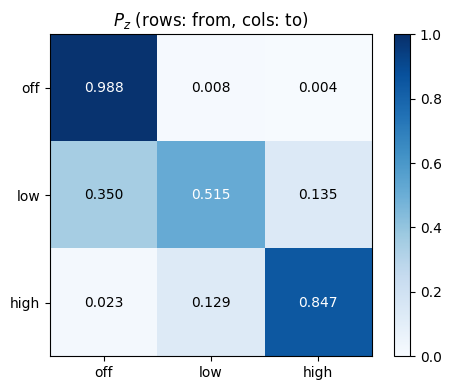

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
im = ax.imshow(params.P_z, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(['off', 'low', 'high'])
ax.set_yticks(range(3)); ax.set_yticklabels(['off', 'low', 'high'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{params.P_z[i,j]:.3f}', ha='center', va='center',
                color='white' if params.P_z[i,j] > 0.5 else 'black')
ax.set_title(r'$P_z$ (rows: from, cols: to)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

---
## Background load: hierarchical model diagnostics

Four figures, all reading `params.eta_bar`, `params.W_eta`, `params.psi_eta`,
`params.a_omega`, `params.b_omega` (see `specs/model.md` §2.1–§2.4):

1. **Prior predictive** — what does the generative model say a new home
   looks like? Center = `eta_bar`. Inner band = ±√E[ω²]. Outer band = 
   ±√(Var(η) + E[ω²]) (the law-of-total-variance prior predictive 1σ).
2. **Per-home empirical vs posterior-MAP envelope** — for each home, the
   solid line/band is the empirical day-mean ± empirical day-std. The
   dashed line/band is the model's posterior MAP for η and ω under the
   *fitted prior*, conditioning on this home's empirical noise scale.
   When the prior is rigid (small `r`, small `psi`), the dashed line
   shrinks toward `eta_bar`; when permissive, dashed ≈ empirical.
3. **Per-home η vs prior** — does this home's mean profile fall inside
   the prior's typical envelope for per-home mean profiles?
4. **Per-home ω vs prior** — does this home's noise profile fall inside
   the prior's typical envelope for per-home noise profiles?

In [32]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
bg_homes_to_plot = [27, 661, 203, 387, 1450]   # None = all homes
show_individual_traces = False   # faint per-day traces under the empirical mean
max_trace_days = 50
# ───────────────────────────────────────────────────────────────────────────

all_home_ids = sorted(train_df['home_id'].unique())
bg_plot_ids  = bg_homes_to_plot if bg_homes_to_plot is not None else all_home_ids
print(f'Plotting {len(bg_plot_ids)} homes')

Plotting 5 homes


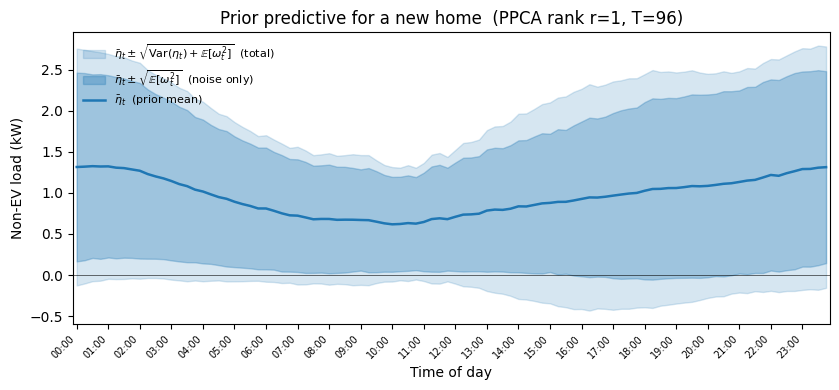

In [33]:
fig_prior = bgp.plot_prior_predictive(params)
plt.show()

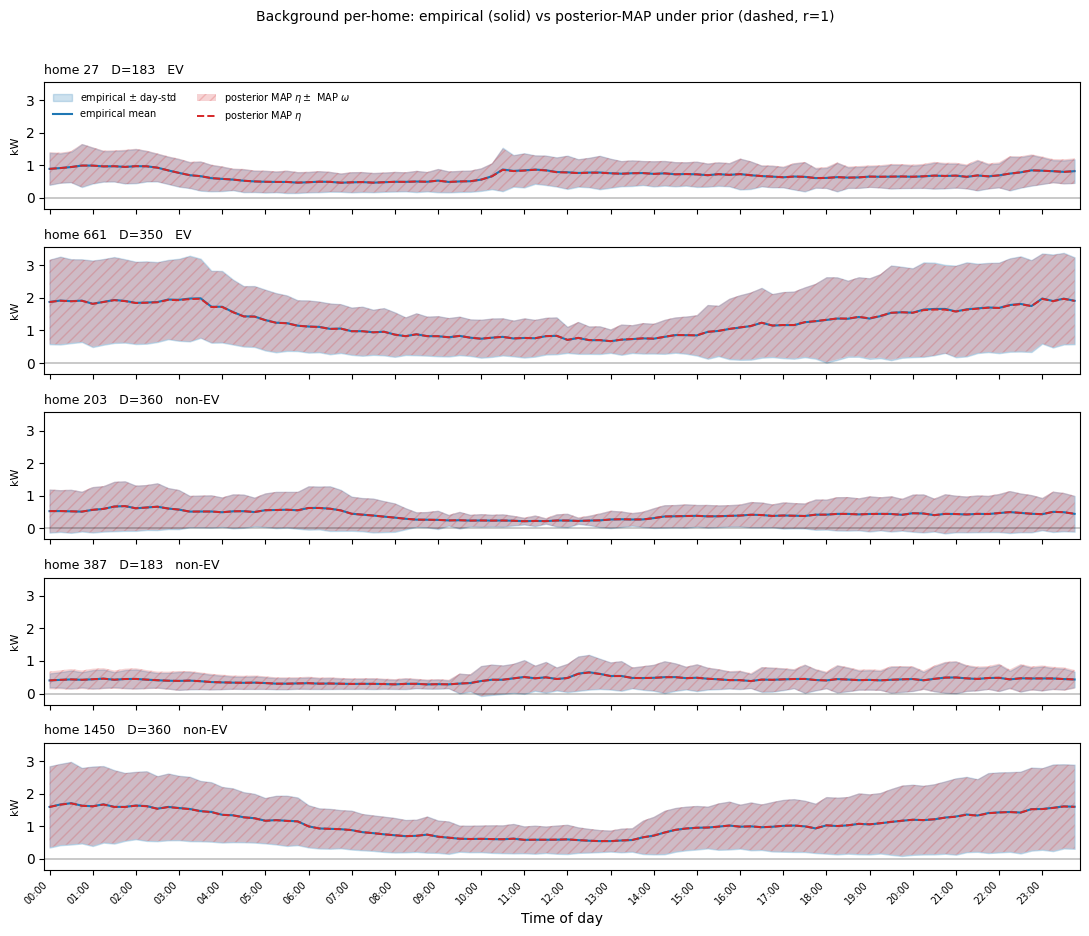

In [34]:
fig_per_home = bgp.plot_background_per_home(
    train_df               = train_df,
    params                 = params,
    home_ids               = bg_plot_ids,
    show_individual_traces = show_individual_traces,
    max_trace_days         = max_trace_days,
)
plt.show()

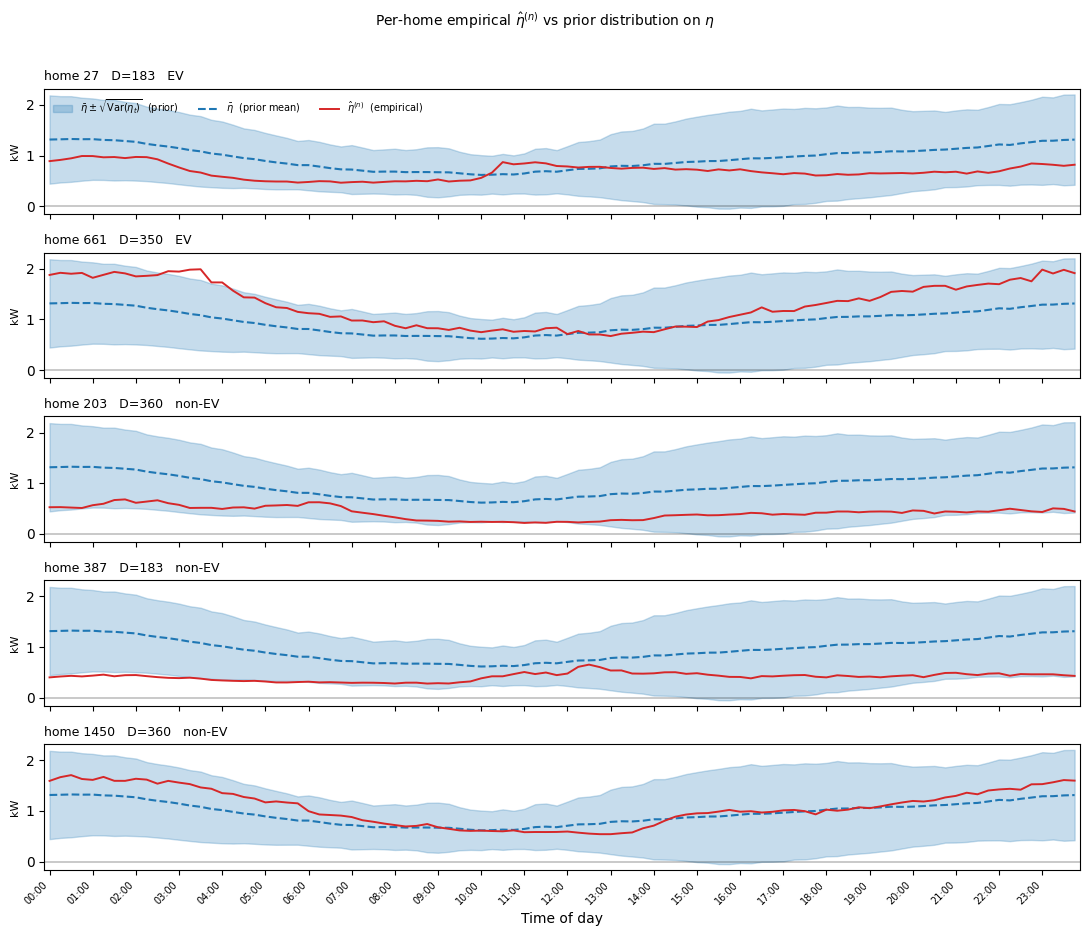

In [35]:
fig_eta = bgp.plot_eta_per_home(
    train_df = train_df,
    params   = params,
    home_ids = bg_plot_ids,
)
plt.show()

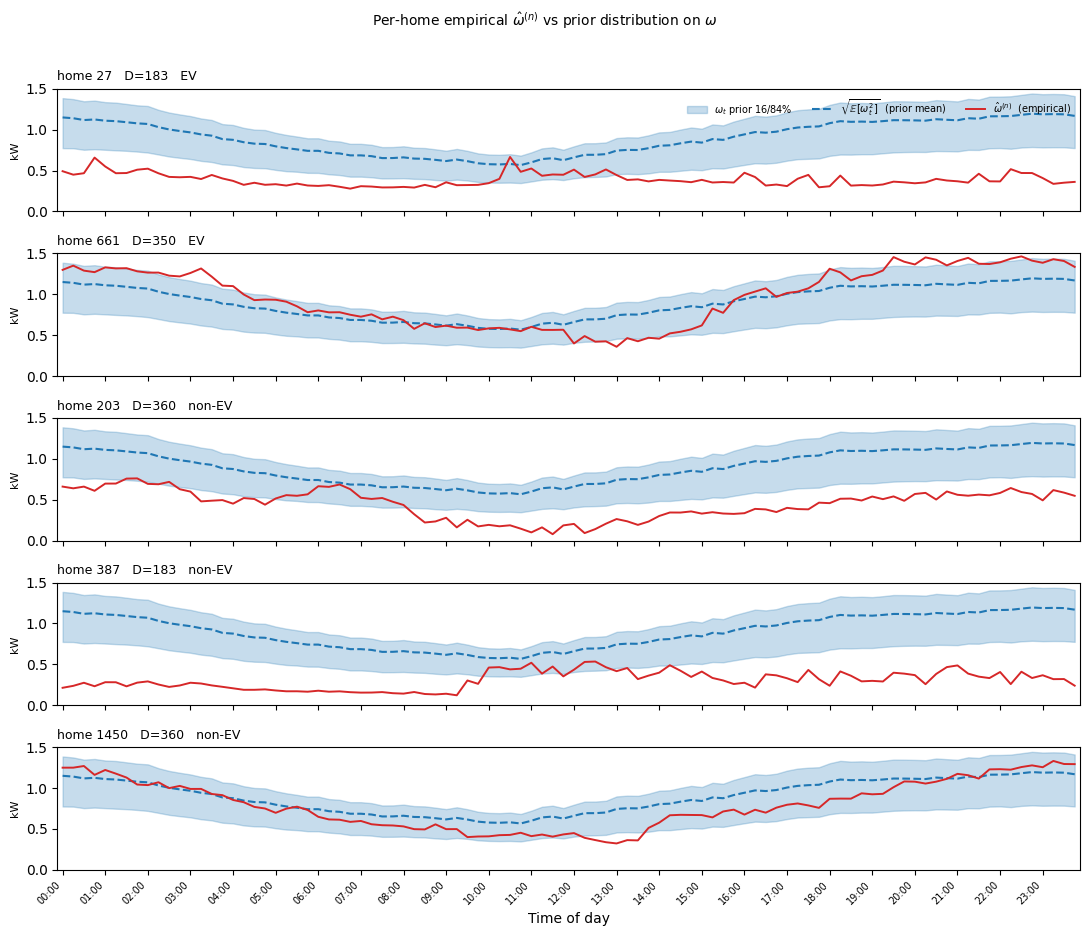

In [10]:
fig_omega = bgp.plot_omega_per_home(
    train_df = train_df,
    params   = params,
    home_ids = bg_plot_ids,
)
plt.show()

---
## EV charging magnitudes: empirical vs model

Two figures (EV homes only for the per-home plot; all homes for the forest plot):
1. **Stacked per-state plots** — one row per EV home.
   x-axis = {off, low, high}; y-axis = EV load in kW, shared absolute scale.
2. **Theta forest plot** — per-home posterior Θ_k ± 1σ vs global prior at x=0.
   Three state values stacked vertically per home, connected by a thin line.

In [11]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
ev_homes_to_plot = [27, 661, 203, 387, 1450]   # None = all homes; or e.g. [27, 661, 4767]
                          # non-EV homes are silently skipped in the per-home plot
                          # but included (faded) in the forest plot

show_individual_points = False   # jittered scatter of raw ev_load obs (downsampled)
show_empirical_band    = True   # empirical mean ± 1 std error bar
show_theta_only_band   = False   # posterior Θ ± posterior std
show_combined_band     = True   # posterior Θ ± sqrt(posterior_std² + sigma_EV²)

max_scatter_points = 300   # max raw observations per state per home
# ───────────────────────────────────────────────────────────────────────────

ev_plot_ids = ev_homes_to_plot if ev_homes_to_plot is not None else all_home_ids
print(f'Using {len(ev_plot_ids)} home IDs')

Using 5 home IDs


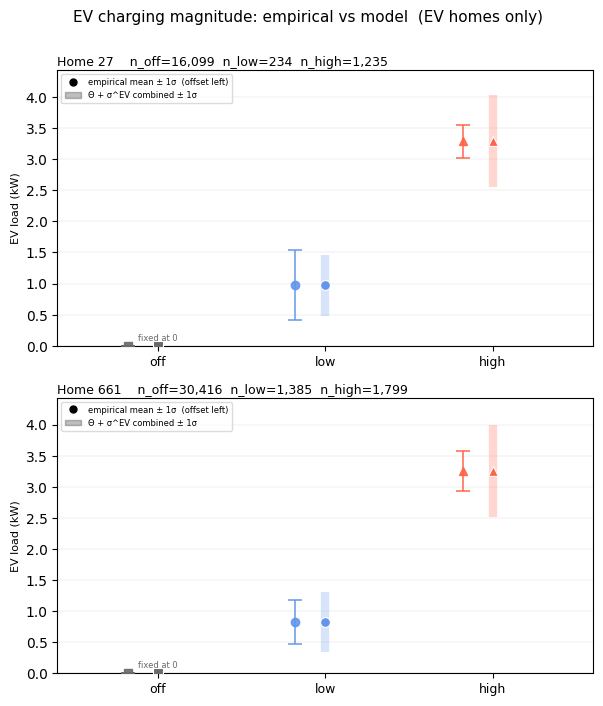

In [12]:
fig_ev_per_home = evp.plot_ev_magnitude_comparison(
    train_df               = train_df,
    params                 = params,
    home_ids               = ev_plot_ids,
    show_individual_points = show_individual_points,
    show_empirical_band    = show_empirical_band,
    show_theta_only_band   = show_theta_only_band,
    show_combined_band     = show_combined_band,
    max_scatter_points     = max_scatter_points,
)
plt.show()

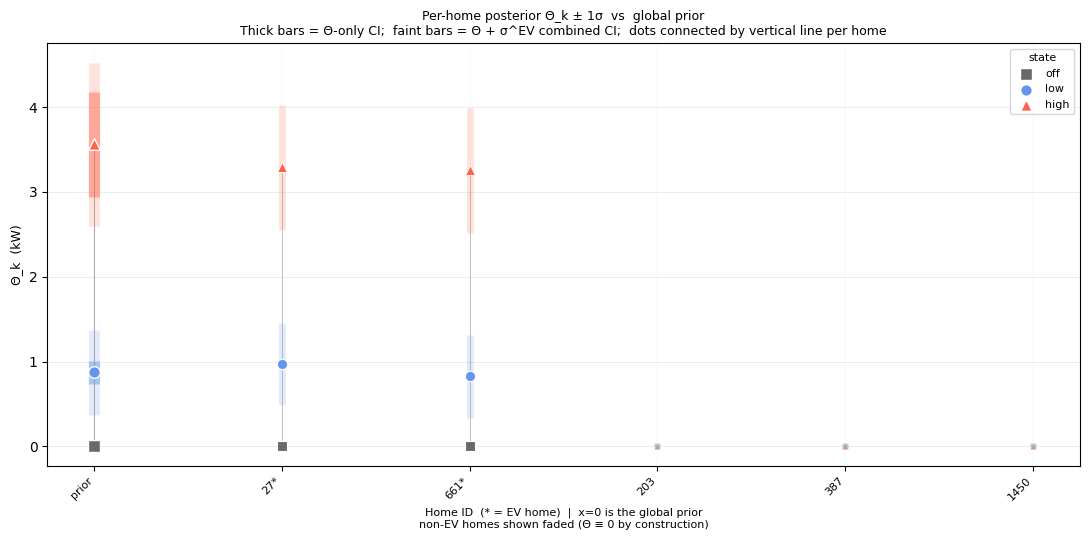

In [13]:
fig_ev_forest = evp.plot_theta_posteriors(
    train_df = train_df,
    params   = params,
    home_ids = ev_plot_ids,
)
plt.show()